# QuantumX CX-01 — Classical ResNet-18 ECG Image Classifier (Claude v2)

**Dataset**: `kanishkarathore1604/ecg-image` — 3,951 12-lead ECG paper-strip images  
**4 Classes**: Normal | Myocardial Infarction | History of MI | Abnormal Heartbeat  
**Architecture**: ResNet-18 (ImageNet) + FC(512→256→4)  

### v2 Fixes
- **CRITICAL**: Fixed `_match_folder()` — was routing History→MI and Abnormal→Normal via substring collision  
- Added class-presence assertions before training  
- Added per-split distribution diagnostics (train/val/test/holdout)  
- Removed `RandomHorizontalFlip` (reverses ECG temporal axis)  
- Added dataset discovery log  
- Added data leakage audit  
- Proper per-class eval during validation

In [1]:
import os, sys, json, time, copy, warnings
from pathlib import Path
from datetime import datetime, timedelta
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models
from PIL import Image

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_fscore_support, matthews_corrcoef, f1_score
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.2)
print('All imports OK')

All imports OK


## 1. Paths & Device

In [2]:
# Hardcoded path — always resolves correctly regardless of kernel CWD
MODEL_ROOT = Path(r'C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude')
ARTIFACTS = MODEL_ROOT / 'artifacts_v1'
GRAPHS = MODEL_ROOT / 'benchmarks'
HOLDOUT = MODEL_ROOT / 'Test Cases - Heart Attack'
ARTIFACTS.mkdir(parents=True, exist_ok=True)
GRAPHS.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(MODEL_ROOT / 'core'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'

print(f'Model Root : {MODEL_ROOT}')
print(f'Artifacts  : {ARTIFACTS}')
print(f'Graphs     : {GRAPHS}')
print(f'Holdout    : {HOLDOUT}')
print(f'Device     : {device} ({gpu_name})')
if torch.cuda.is_available():
    print(f'GPU Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Model Root : C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude
Artifacts  : C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\artifacts_v1
Graphs     : C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\benchmarks
Holdout    : C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\Test Cases - Heart Attack
Device     : cuda (NVIDIA GeForce RTX 3050 Laptop GPU)
GPU Memory : 4.3 GB


## 2. Load & Audit Dataset (Critical Section)

In [3]:
from ecg_image_dataset import (
    create_cardiac_dataloaders, CardiacECGImageDataset,
    CLASS_NAMES, NUM_CLASSES, CLINICAL_DESCRIPTIONS,
    get_val_transforms, get_train_transforms,
    find_dataset_root, _match_folder,
    IMAGENET_MEAN, IMAGENET_STD, HOLDOUT_DIR
)

# === STEP 1: Verify folder-to-class mapping BEFORE loading ===
root = find_dataset_root()
print(f'Dataset root: {root}')
print(f'\n=== FOLDER → CLASS MAPPING VERIFICATION ===')
for split in ['train', 'test']:
    split_dir = root / split
    if not split_dir.exists():
        continue
    print(f'\n  {split.upper()} folders:')
    for folder in sorted(os.listdir(split_dir)):
        fp = split_dir / folder
        if not fp.is_dir():
            continue
        cidx = _match_folder(folder)
        n_files = len([f for f in os.listdir(fp) if os.path.isfile(fp / f)])
        cls_name = CLASS_NAMES[cidx] if cidx is not None else 'UNMATCHED'
        status = '✓' if cidx is not None else '✗ MISSING'
        print(f'    {status} "{folder}" → class {cidx} = {cls_name} ({n_files} files)')

Dataset root: C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\data\ecg_images\ECG_DATA

=== FOLDER → CLASS MAPPING VERIFICATION ===

  TRAIN folders:
    ✓ "ECG Images of Myocardial Infarction Patients (240x12=2880)" → class 1 = Myocardial Infarction (956 files)
    ✓ "ECG Images of Patient that have History of MI (172x12=2064)" → class 2 = History of MI (516 files)
    ✓ "ECG Images of Patient that have abnormal heartbeat (233x12=2796)" → class 3 = Abnormal Heartbeat (699 files)
    ✓ "Normal Person ECG Images (284x12=3408)" → class 0 = Normal (852 files)

  TEST folders:
    ✓ "ECG Images of Myocardial Infarction Patients (240x12=2880)" → class 1 = Myocardial Infarction (239 files)
    ✓ "ECG Images of Patient that have History of MI (172x12=2064)" → class 2 = History of MI (172 files)
    ✓ "ECG Images of Patient that have abnormal heartbeat (233x12=2796)" → class 3 = Abnormal Heartbeat (233 files)
    ✓ "Normal Person ECG Images (284x12=3408)"

In [4]:
# === STEP 2: Create dataloaders (will print full diagnostics + assertions) ===
data = create_cardiac_dataloaders(
    batch_size=32, image_size=224, num_workers=2,
    holdout_per_class=30, val_split=0.15, seed=42
)

train_loader = data['train_loader']
val_loader = data['val_loader']
test_loader = data['test_loader']
class_weights = data['class_weights'].to(device)
summary = data['dataset_summary']
dataset_root = data['dataset_root']

print(f"\n{'='*60}")
print(f'DATASET AUDIT PASSED — All 4 classes present in all splits')
print(f"{'='*60}")
print(f"\nTrain:   {summary['train_samples']:>5} images  {summary['train_distribution']}")
print(f"Val:     {summary['val_samples']:>5} images  {summary['val_distribution']}")
print(f"Test:    {summary['test_samples']:>5} images  {summary['test_distribution']}")
print(f"Holdout: {summary['holdout_samples']:>5} images  {summary['holdout_distribution']}")
print(f"\nClass Weights: {[f'{w:.3f}' for w in class_weights.cpu().tolist()]}")
print(f"Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")


  Dataset root: C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\data\ecg_images\ECG_DATA
  Train dir:    C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\data\ecg_images\ECG_DATA\train (exists=True)
  Test dir:     C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\data\ecg_images\ECG_DATA\test (exists=True)



  Holdout extracted: 120 images
    Myocardial Infarction: 30
    History of MI: 30
    Abnormal Heartbeat: 30
    Normal: 30

  --- TRAIN Discovery ---

  Dataset Discovery Log:
  Folder Name                                                  Matched                    Files   Excl
  ----------------------------------------------------------------------------------------------------
  ECG Images of Myocardial Infarction Patients (240x12=2880)   Myocardial Infarction        956      0
  ECG Images of Patient that have History of MI (172x12=2064)  History of MI                516      0
  ECG Images of Patient that have abnormal heartbeat (233x12=2796) Abnormal Heartbeat           699      0
  Normal Person ECG Images (284x12=3408)                       Normal                       852      0

  --- TEST Discovery ---

  Dataset Discovery Log:
  Folder Name                                                  Matched                    Files   Excl
  -----------------------------------------

In [5]:
# === STEP 3: Independent label verification from DataLoaders ===
# Don't trust summary alone — count directly from loaders
print('\n=== INDEPENDENT LABEL VERIFICATION ===')
for name, loader in [('Train', train_loader), ('Val', val_loader), ('Test', test_loader)]:
    label_counter = Counter()
    paths_sample = []
    for batch in loader:
        imgs, lbls, paths = batch
        for l in lbls.numpy():
            label_counter[CLASS_NAMES[l]] += 1
        if len(paths_sample) < 3:
            paths_sample.extend(paths[:3])
    print(f'\n  {name}: {dict(label_counter)}')
    print(f'  Total: {sum(label_counter.values())}')
    print(f'  Sample paths (3rd value = file path):')
    for p in paths_sample[:3]:
        print(f'    {p}')

# === STEP 4: Train/Test path overlap check (data leakage audit) ===
print('\n=== DATA LEAKAGE AUDIT ===')
train_paths = set()
for _, _, paths in train_loader:
    train_paths.update(paths)
test_paths = set()
for _, _, paths in test_loader:
    test_paths.update(paths)
val_paths = set()
for _, _, paths in val_loader:
    val_paths.update(paths)

tv_overlap = train_paths & val_paths
tt_overlap = train_paths & test_paths
vt_overlap = val_paths & test_paths
print(f'  Train ∩ Val  overlap: {len(tv_overlap)} (must be 0)')
print(f'  Train ∩ Test overlap: {len(tt_overlap)} (must be 0)')
print(f'  Val ∩ Test   overlap: {len(vt_overlap)} (must be 0)')

if tv_overlap or tt_overlap or vt_overlap:
    print('\n  ⚠️ DATA LEAKAGE DETECTED — DO NOT TRUST RESULTS')
else:
    print('\n  ✓ No data leakage detected — splits are clean')


=== INDEPENDENT LABEL VERIFICATION ===

  Train: {'History of MI': 622, 'Normal': 630, 'Myocardial Infarction': 642, 'Abnormal Heartbeat': 666}
  Total: 2560
  Sample paths (3rd value = file path):
    C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\data\ecg_images\ECG_DATA\train\ECG Images of Patient that have History of MI (172x12=2064)\PMI(56) - Copy.jpg
    C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\data\ecg_images\ECG_DATA\train\Normal Person ECG Images (284x12=3408)\Normal(375) - Copy.jpg
    C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\data\ecg_images\ECG_DATA\train\ECG Images of Myocardial Infarction Patients (240x12=2880)\MI(56) - Copy.jpg

  Val: {'Normal': 120, 'Myocardial Infarction': 137, 'Abnormal Heartbeat': 111, 'History of MI': 85}
  Total: 453
  Sample paths (3rd value = file path):
    C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart

## 3. Build Model

In [6]:
def build_classical_model(nc=4):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.ReLU(True),
        nn.Dropout(0.2),
        nn.Linear(256, nc)
    )
    return m

model = build_classical_model(NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Architecture: ResNet-18 + FC Head')
print(f'Output neurons:   {NUM_CLASSES} (one per class)')
print(f'Total params:     {total_params:>12,}')
print(f'Trainable params: {train_params:>12,}')
print(f'Frozen params:    {total_params - train_params:>12,}')
print(f'\nNote: Entire ResNet-18 is fine-tuned (no layer freezing).')
print(f'FC Head: 512 → Dropout(0.3) → 256 → ReLU → Dropout(0.2) → {NUM_CLASSES}')

Architecture: ResNet-18 + FC Head
Output neurons:   4 (one per class)
Total params:       11,308,868
Trainable params:   11,308,868
Frozen params:               0

Note: Entire ResNet-18 is fine-tuned (no layer freezing).
FC Head: 512 → Dropout(0.3) → 256 → ReLU → Dropout(0.2) → 4


## 4. Training Configuration

In [7]:
EPOCHS   = 30
LR       = 1e-3
WD       = 1e-4
PATIENCE = 8

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Epochs:    {EPOCHS}')
print(f'LR:        {LR} (applied to entire network)')
print(f'Optimizer: Adam (weight_decay={WD})')
print(f'Scheduler: CosineAnnealing (T_max={EPOCHS}, eta_min=1e-6)')
print(f'Patience:  {PATIENCE} (early stop if no strict val_acc improvement)')
print(f'Loss:      CrossEntropyLoss (class-weighted)')
print(f'\nNote: LR displayed each epoch is the POST-scheduler-step value,')
print(f'      i.e. the LR that will be used for the NEXT epoch.')

Epochs:    30
LR:        0.001 (applied to entire network)
Optimizer: Adam (weight_decay=0.0001)
Scheduler: CosineAnnealing (T_max=30, eta_min=1e-6)
Patience:  8 (early stop if no strict val_acc improvement)
Loss:      CrossEntropyLoss (class-weighted)

Note: LR displayed each epoch is the POST-scheduler-step value,
      i.e. the LR that will be used for the NEXT epoch.


## 5. Train — Every Epoch Individually

Each epoch prints:
- Per-batch progress (overwriting line)
- Final epoch summary with timing
- Early stop uses val_loss as tie-breaker when val_acc is equal

In [8]:
hist = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'lr': [], 'epoch_time': []
}
best_acc = 0.0
best_loss = float('inf')
best_state = None
best_epoch = 0
patience_counter = 0
total_start = time.time()

print('=' * 115)
print('  TRAINING CX-01 CARDIAC CLASSICAL MODEL — ResNet-18 on 4-Class ECG Images')
print('=' * 115)
print(f'{"Epoch":>7} | {"TrLoss":>8} {"TrAcc":>7} | {"VaLoss":>8} {"VaAcc":>7} | {"LR":>10} | {"Time":>8} | {"Total":>8} | Status')
print('-' * 115)

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # ── TRAIN ──
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    n_batches = len(train_loader)

    for batch_idx, (images, labels, _) in enumerate(train_loader, 1):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if batch_idx % 5 == 0 or batch_idx == n_batches:
            batch_acc = 100.0 * correct / total
            print(f'\r  Epoch {epoch:02d} | Batch {batch_idx:>4d}/{n_batches} | Loss: {loss.item():.4f} | RunAcc: {batch_acc:.1f}%', end='', flush=True)

    train_loss = running_loss / total
    train_acc = 100.0 * correct / total

    # ── VALIDATE ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss_epoch = val_loss / val_total
    val_acc = 100.0 * val_correct / val_total

    # LR is the post-step value (used for NEXT epoch)
    scheduler.step()
    lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - epoch_start
    total_elapsed = time.time() - total_start

    hist['train_loss'].append(train_loss)
    hist['val_loss'].append(val_loss_epoch)
    hist['train_acc'].append(train_acc)
    hist['val_acc'].append(val_acc)
    hist['lr'].append(lr)
    hist['epoch_time'].append(epoch_time)

    # Best model selection: val_acc primary, val_loss tie-breaker
    status = ''
    if val_acc > best_acc or (val_acc == best_acc and val_loss_epoch < best_loss):
        best_acc = val_acc
        best_loss = val_loss_epoch
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        patience_counter = 0
        status = '★ BEST'
    else:
        patience_counter += 1
        status = f'  (patience {patience_counter}/{PATIENCE})'

    et = str(timedelta(seconds=int(epoch_time)))
    tt = str(timedelta(seconds=int(total_elapsed)))
    print(f'\r  {epoch:02d}/{EPOCHS:02d}  | {train_loss:>8.4f} {train_acc:>6.1f}% | {val_loss_epoch:>8.4f} {val_acc:>6.1f}% | {lr:>10.6f} | {et:>8} | {tt:>8} | {status}')

    if patience_counter >= PATIENCE:
        print(f'\n  ⚡ Early stopping at epoch {epoch}. Best: epoch {best_epoch} (val_acc={best_acc:.2f}%, val_loss={best_loss:.6f})')
        break

total_time = time.time() - total_start
print('-' * 115)
print(f'  Training complete in {str(timedelta(seconds=int(total_time)))}')
print(f'  Best checkpoint: epoch {best_epoch} — val_acc={best_acc:.2f}%, val_loss={best_loss:.6f}')
print(f'  Average epoch time: {np.mean(hist["epoch_time"]):.1f}s')

# Load best checkpoint
model.load_state_dict(best_state)
print(f'  Loaded best checkpoint from epoch {best_epoch}')

  TRAINING CX-01 CARDIAC CLASSICAL MODEL — ResNet-18 on 4-Class ECG Images
  Epoch |   TrLoss   TrAcc |   VaLoss   VaAcc |         LR |     Time |    Total | Status
-------------------------------------------------------------------------------------------------------------------
  01/30  |   0.4624   83.3% |   2.0184   60.3% |   0.000997 |  0:01:53 |  0:01:53 | ★ BEST
  02/30  |   0.2108   93.0% |   0.8465   81.9% |   0.000989 |  0:01:49 |  0:03:43 | ★ BEST
  03/30  |   0.1706   94.6% |   0.1075   96.7% |   0.000976 |  0:01:58 |  0:05:41 | ★ BEST
  04/30  |   0.1696   95.1% |   1.5937   56.5% |   0.000957 |  0:01:58 |  0:07:39 |   (patience 1/8)
  05/30  |   0.1444   95.5% |   1.6507   75.9% |   0.000933 |  0:01:52 |  0:09:31 |   (patience 2/8)
  06/30  |   0.0922   97.2% |   0.0957   96.9% |   0.000905 |  0:01:47 |  0:11:18 | ★ BEST
  07/30  |   0.0991   97.1% |   0.0615   98.2% |   0.000872 |  0:01:47 |  0:13:06 | ★ BEST
  08/30  |   0.0690   98.0% |   0.0309   99.3% |   0.000835 | 

## 6. Save Model

In [9]:
torch.save({
    'state_dict': best_state,
    'classes': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'architecture': 'ResNet-18 + FC(512->256->4)',
    'best_val_acc': best_acc,
    'best_val_loss': best_loss,
    'best_epoch': best_epoch,
    'total_params': total_params,
    'training_time_s': total_time,
    'epochs_trained': len(hist['train_loss']),
}, ARTIFACTS / 'cardiac_cnn_production.pt')

# Encoder for quantum pipeline
encoder = copy.deepcopy(model)
encoder.fc = nn.Identity()
torch.save({'state_dict': encoder.state_dict(), 'output_dim': 512},
           ARTIFACTS / 'cardiac_encoder.pt')

print(f'Saved: {ARTIFACTS / "cardiac_cnn_production.pt"}')
print(f'Saved: {ARTIFACTS / "cardiac_encoder.pt"}')
print(f'Model size: {os.path.getsize(ARTIFACTS / "cardiac_cnn_production.pt") / 1e6:.1f} MB')

Saved: C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\artifacts_v1\cardiac_cnn_production.pt
Saved: C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\artifacts_v1\cardiac_encoder.pt
Model size: 45.3 MB


## 7. Test Set Evaluation (Independent — Never Seen During Training)

In [10]:
model.eval()
test_loss_total, test_correct, test_total = 0.0, 0, 0
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels, paths in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss_total += loss.item() * images.size(0)
        probs = torch.softmax(outputs, 1)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_loss = test_loss_total / test_total
test_acc = 100.0 * test_correct / test_total
preds = np.array(all_preds)
labels_arr = np.array(all_labels)
probs_arr = np.array(all_probs)

mcc = matthews_corrcoef(labels_arr, preds)
prec, rec, f1s, support = precision_recall_fscore_support(labels_arr, preds, average=None)
macro_f1 = float(f1_score(labels_arr, preds, average='macro'))
weighted_f1 = float(f1_score(labels_arr, preds, average='weighted'))

print('=' * 70)
print('  TEST RESULTS — CX-01 Classical (ResNet-18) — INDEPENDENT TEST SET')
print('=' * 70)
print(f'  Test Accuracy  : {test_acc:.2f}%')
print(f'  Test Loss      : {test_loss:.6f}')
print(f'  Macro F1       : {macro_f1:.4f}')
print(f'  Weighted F1    : {weighted_f1:.4f}')
print(f'  MCC            : {mcc:.4f}')
print(f'  Best Val Acc   : {best_acc:.2f}% (epoch {best_epoch})')
print()
print('  This is the FINAL metric on data never seen during training or validation.')
print()
print(classification_report(labels_arr, preds, target_names=CLASS_NAMES, digits=4))

# Per-class support check
print('\n  Per-class support in test set:')
for i in range(NUM_CLASSES):
    cnt = int(support[i]) if support is not None else int(np.sum(labels_arr == i))
    print(f'    {CLASS_NAMES[i]:<25} {cnt:>5} samples')

  TEST RESULTS — CX-01 Classical (ResNet-18) — INDEPENDENT TEST SET
  Test Accuracy  : 100.00%
  Test Loss      : 0.000233
  Macro F1       : 1.0000
  Weighted F1    : 1.0000
  MCC            : 1.0000
  Best Val Acc   : 100.00% (epoch 25)

  This is the FINAL metric on data never seen during training or validation.

                       precision    recall  f1-score   support

               Normal     1.0000    1.0000    1.0000       254
Myocardial Infarction     1.0000    1.0000    1.0000       209
        History of MI     1.0000    1.0000    1.0000       142
   Abnormal Heartbeat     1.0000    1.0000    1.0000       203

             accuracy                         1.0000       808
            macro avg     1.0000    1.0000    1.0000       808
         weighted avg     1.0000    1.0000    1.0000       808


  Per-class support in test set:
    Normal                      254 samples
    Myocardial Infarction       209 samples
    History of MI               142 samples
    Abnor

## 8. Training Graphs

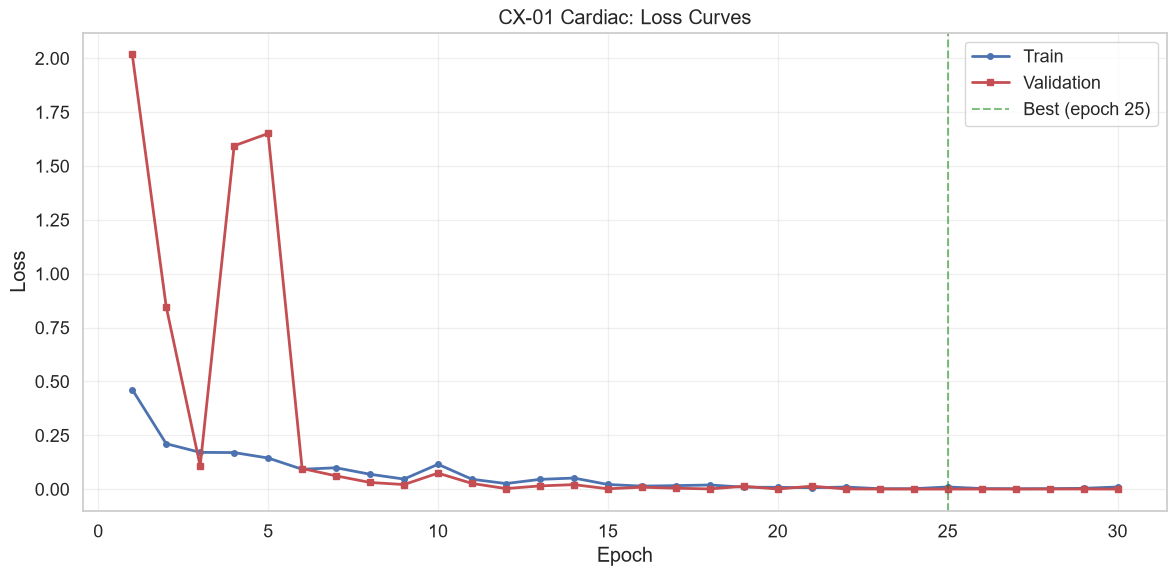

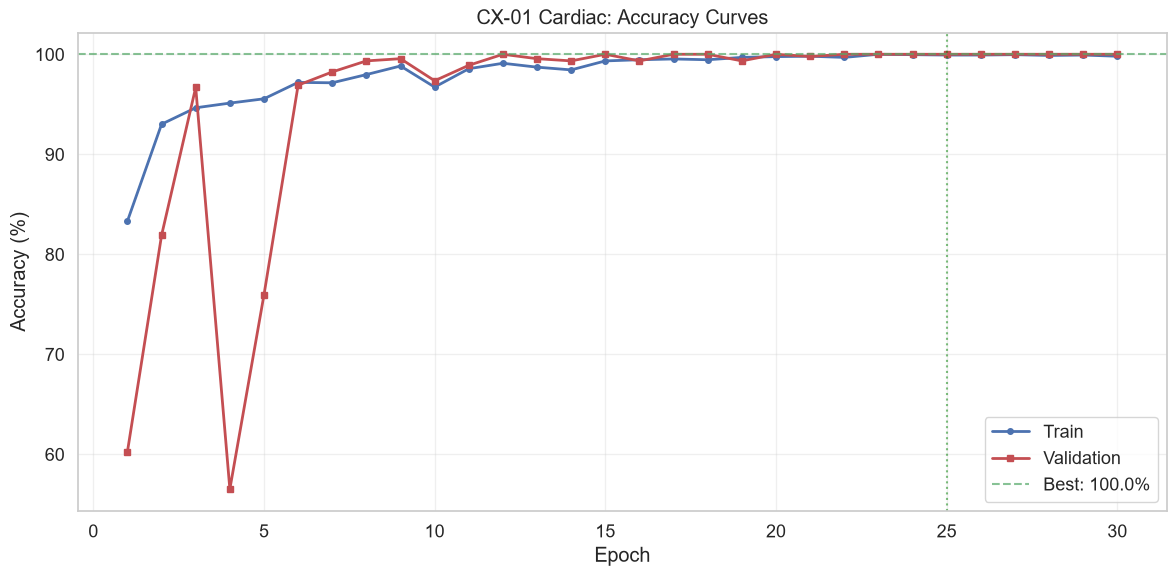

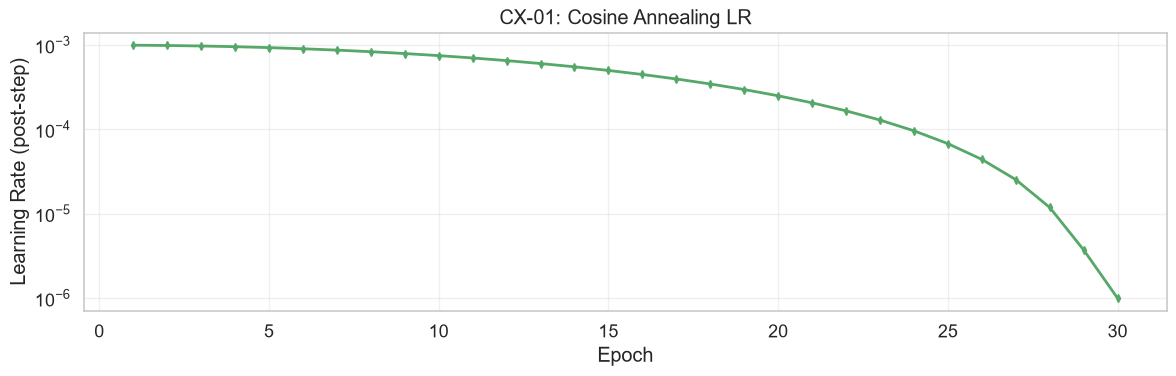

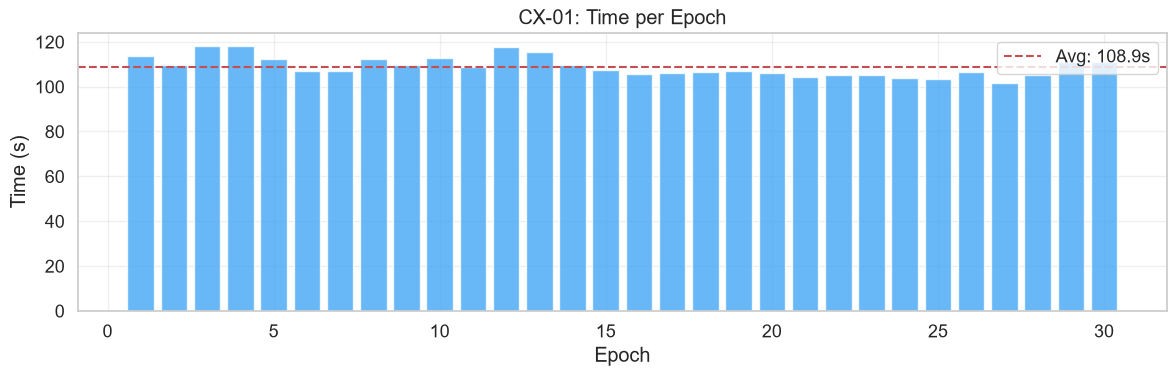

Saved 4 training graphs to C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\benchmarks


In [11]:
eps = range(1, len(hist['train_loss']) + 1)

# 8.1 Loss Curves
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(eps, hist['train_loss'], 'b-o', ms=4, lw=2, label='Train')
ax.plot(eps, hist['val_loss'], 'r-s', ms=4, lw=2, label='Validation')
ax.axvline(best_epoch, color='green', ls='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
ax.set(xlabel='Epoch', ylabel='Loss', title='CX-01 Cardiac: Loss Curves')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(GRAPHS / 'classical_loss_curves.png', dpi=150); plt.show()

# 8.2 Accuracy Curves
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(eps, hist['train_acc'], 'b-o', ms=4, lw=2, label='Train')
ax.plot(eps, hist['val_acc'], 'r-s', ms=4, lw=2, label='Validation')
ax.axhline(best_acc, color='g', ls='--', alpha=0.7, label=f'Best: {best_acc:.1f}%')
ax.axvline(best_epoch, color='green', ls=':', alpha=0.5)
ax.set(xlabel='Epoch', ylabel='Accuracy (%)', title='CX-01 Cardiac: Accuracy Curves')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(GRAPHS / 'classical_accuracy_curves.png', dpi=150); plt.show()

# 8.3 LR Schedule
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(eps, hist['lr'], 'g-d', ms=4, lw=2)
ax.set_yscale('log')
ax.set(xlabel='Epoch', ylabel='Learning Rate (post-step)', title='CX-01: Cosine Annealing LR')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(GRAPHS / 'classical_lr_schedule.png', dpi=150); plt.show()

# 8.4 Epoch Time
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(eps, hist['epoch_time'], color='#42A5F5', alpha=0.8)
ax.axhline(np.mean(hist['epoch_time']), color='r', ls='--', label=f'Avg: {np.mean(hist["epoch_time"]):.1f}s')
ax.set(xlabel='Epoch', ylabel='Time (s)', title='CX-01: Time per Epoch')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(GRAPHS / 'classical_epoch_times.png', dpi=150); plt.show()

print(f'Saved 4 training graphs to {GRAPHS}')

## 9. Test Evaluation Graphs

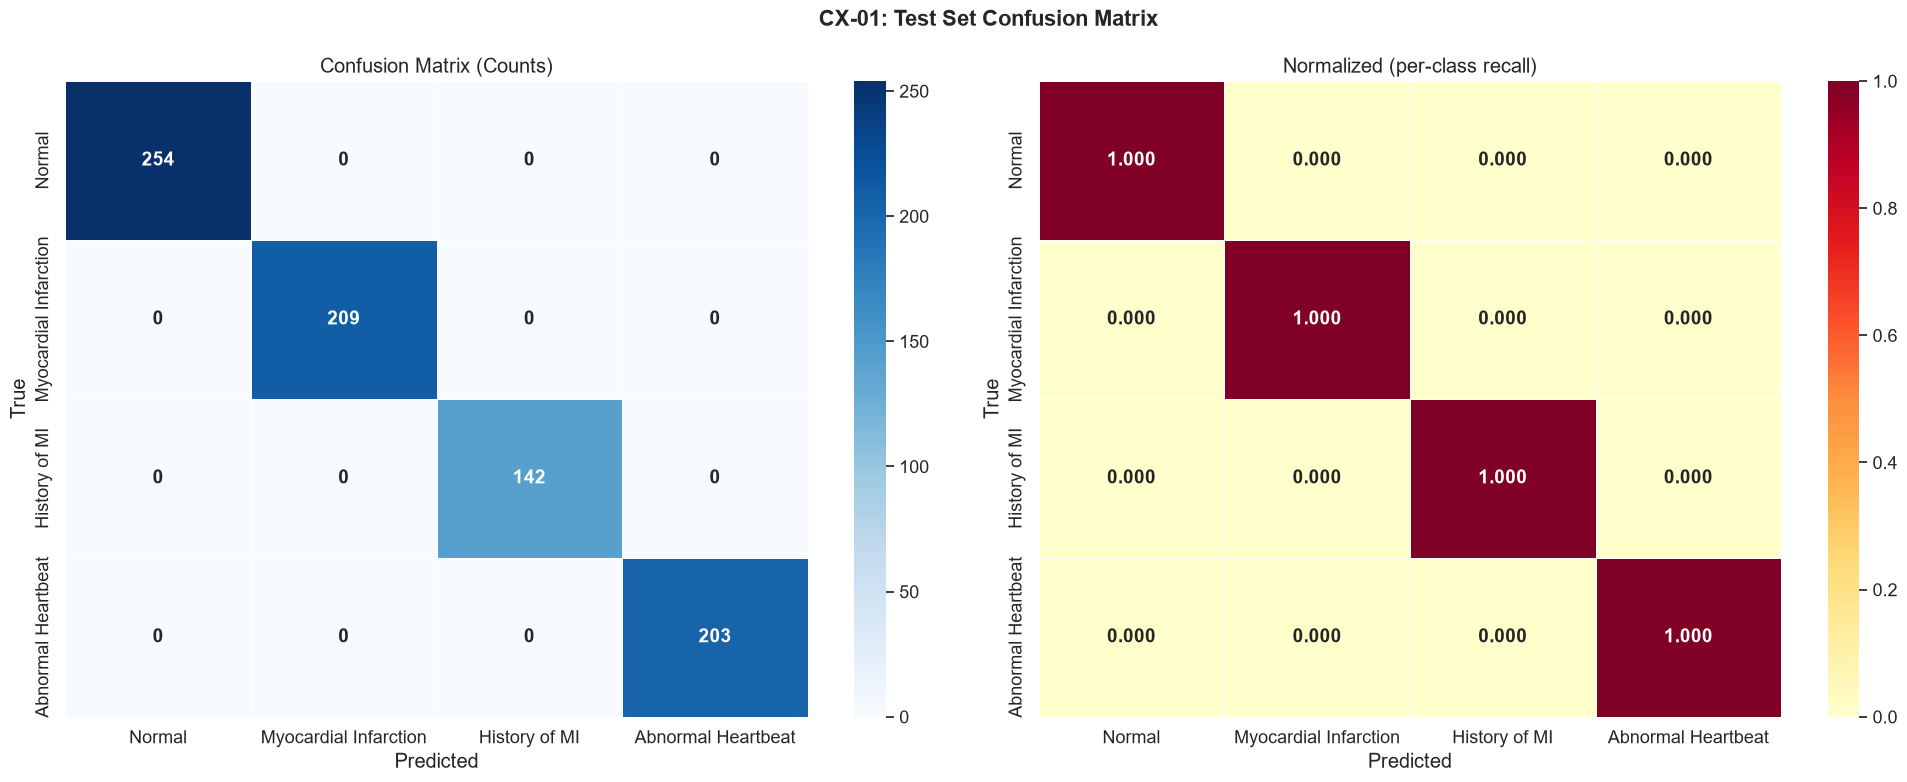

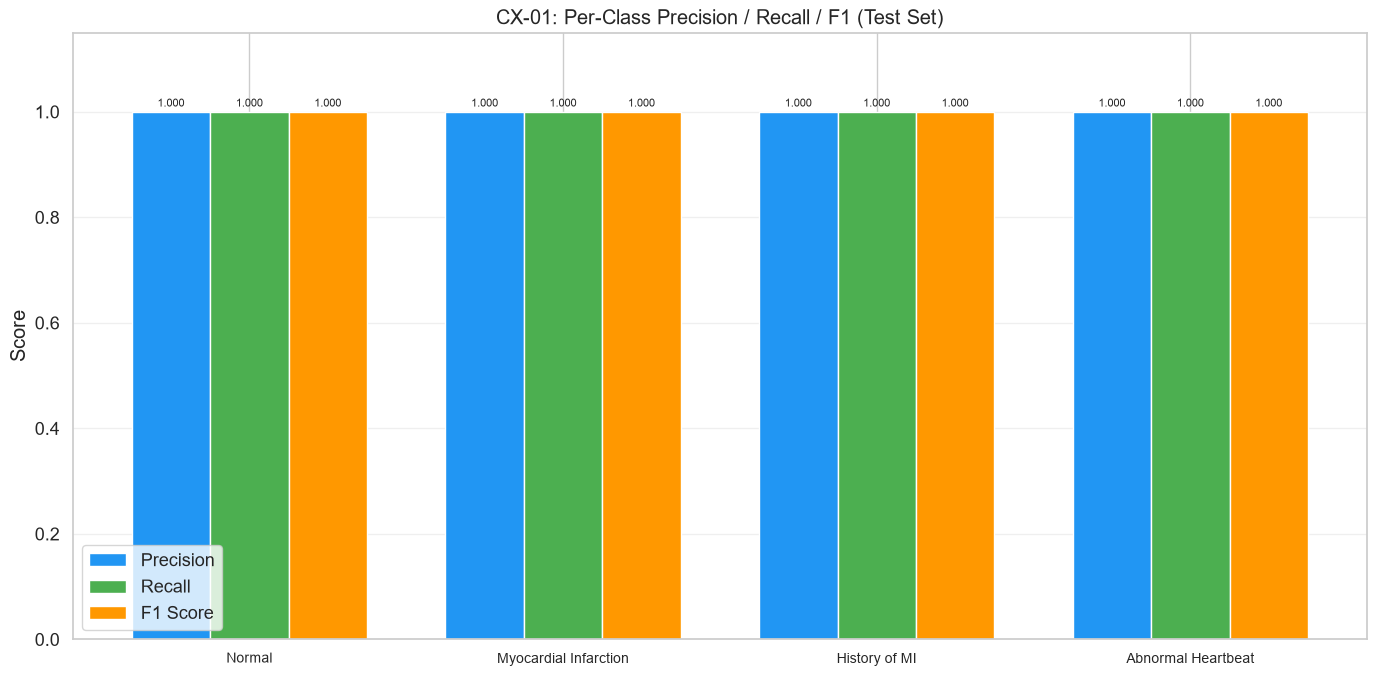

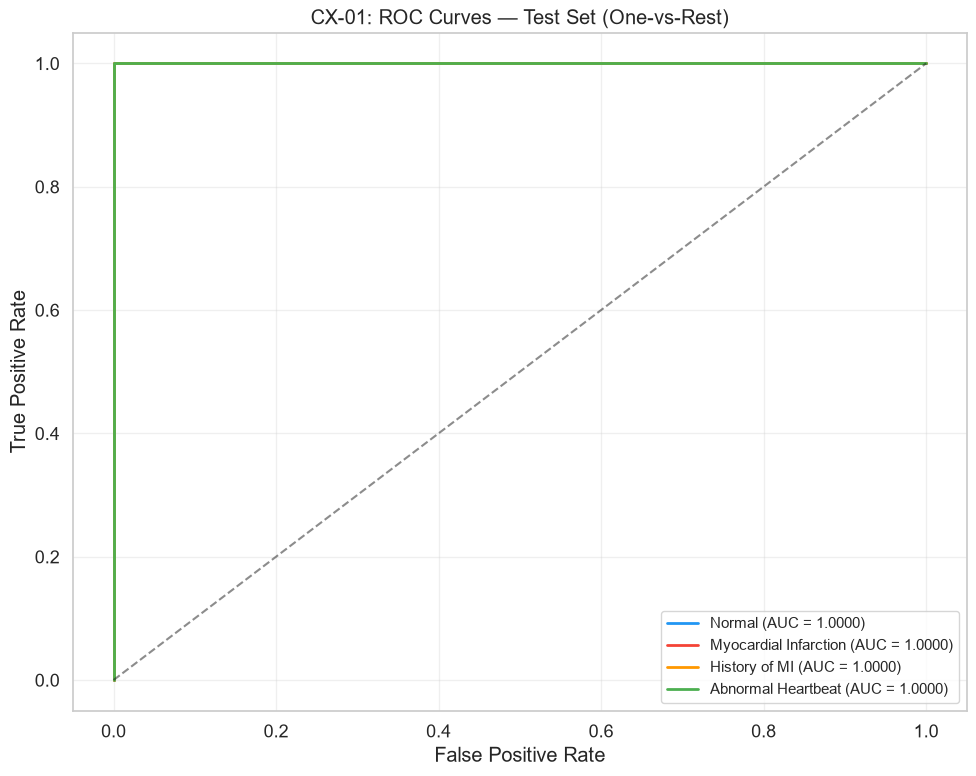


Macro AUC: 1.0000
  Normal: 1.0000
  Myocardial Infarction: 1.0000
  History of MI: 1.0000
  Abnormal Heartbeat: 1.0000


In [12]:
# 9.1 Confusion Matrix (Counts + Normalized)
cm = confusion_matrix(labels_arr, preds)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax1, annot_kws={'size': 14, 'weight': 'bold'}, linewidths=0.5)
ax1.set(xlabel='Predicted', ylabel='True', title='Confusion Matrix (Counts)')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='YlOrRd', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax2, annot_kws={'size': 14, 'weight': 'bold'}, linewidths=0.5, vmin=0, vmax=1)
ax2.set(xlabel='Predicted', ylabel='True', title='Normalized (per-class recall)')

plt.suptitle('CX-01: Test Set Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig(GRAPHS / 'classical_confusion_matrix.png', dpi=150); plt.show()

# 9.2 Per-Class Metrics
x = np.arange(NUM_CLASSES); w = 0.25
fig, ax = plt.subplots(figsize=(14, 7))
b1 = ax.bar(x - w, prec, w, label='Precision', color='#2196F3')
b2 = ax.bar(x, rec, w, label='Recall', color='#4CAF50')
b3 = ax.bar(x + w, f1s, w, label='F1 Score', color='#FF9800')
ax.set(xticks=x, ylabel='Score', title='CX-01: Per-Class Precision / Recall / F1 (Test Set)')
ax.set_xticklabels(CLASS_NAMES, fontsize=10)
ax.legend(); ax.set_ylim(0, 1.15); ax.grid(alpha=0.3, axis='y')
for bars in [b1, b2, b3]:
    for b in bars:
        ax.annotate(f'{b.get_height():.3f}', (b.get_x() + b.get_width()/2, b.get_height()),
                    ha='center', va='bottom', fontsize=8, textcoords='offset points', xytext=(0, 2))
plt.tight_layout(); plt.savefig(GRAPHS / 'classical_per_class_metrics.png', dpi=150); plt.show()

# 9.3 ROC Curves
lbin = label_binarize(labels_arr, classes=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2196F3', '#F44336', '#FF9800', '#4CAF50']
aucs = {}
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(lbin[:, i], probs_arr[:, i])
    a = auc(fpr, tpr); aucs[CLASS_NAMES[i]] = float(a)
    ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{CLASS_NAMES[i]} (AUC = {a:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='CX-01: ROC Curves — Test Set (One-vs-Rest)')
ax.legend(fontsize=11, loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(GRAPHS / 'classical_roc_curves.png', dpi=150); plt.show()

macro_auc = float(np.mean(list(aucs.values())))
print(f'\nMacro AUC: {macro_auc:.4f}')
for k, v in aucs.items():
    print(f'  {k}: {v:.4f}')

## 10. Grad-CAM Localization

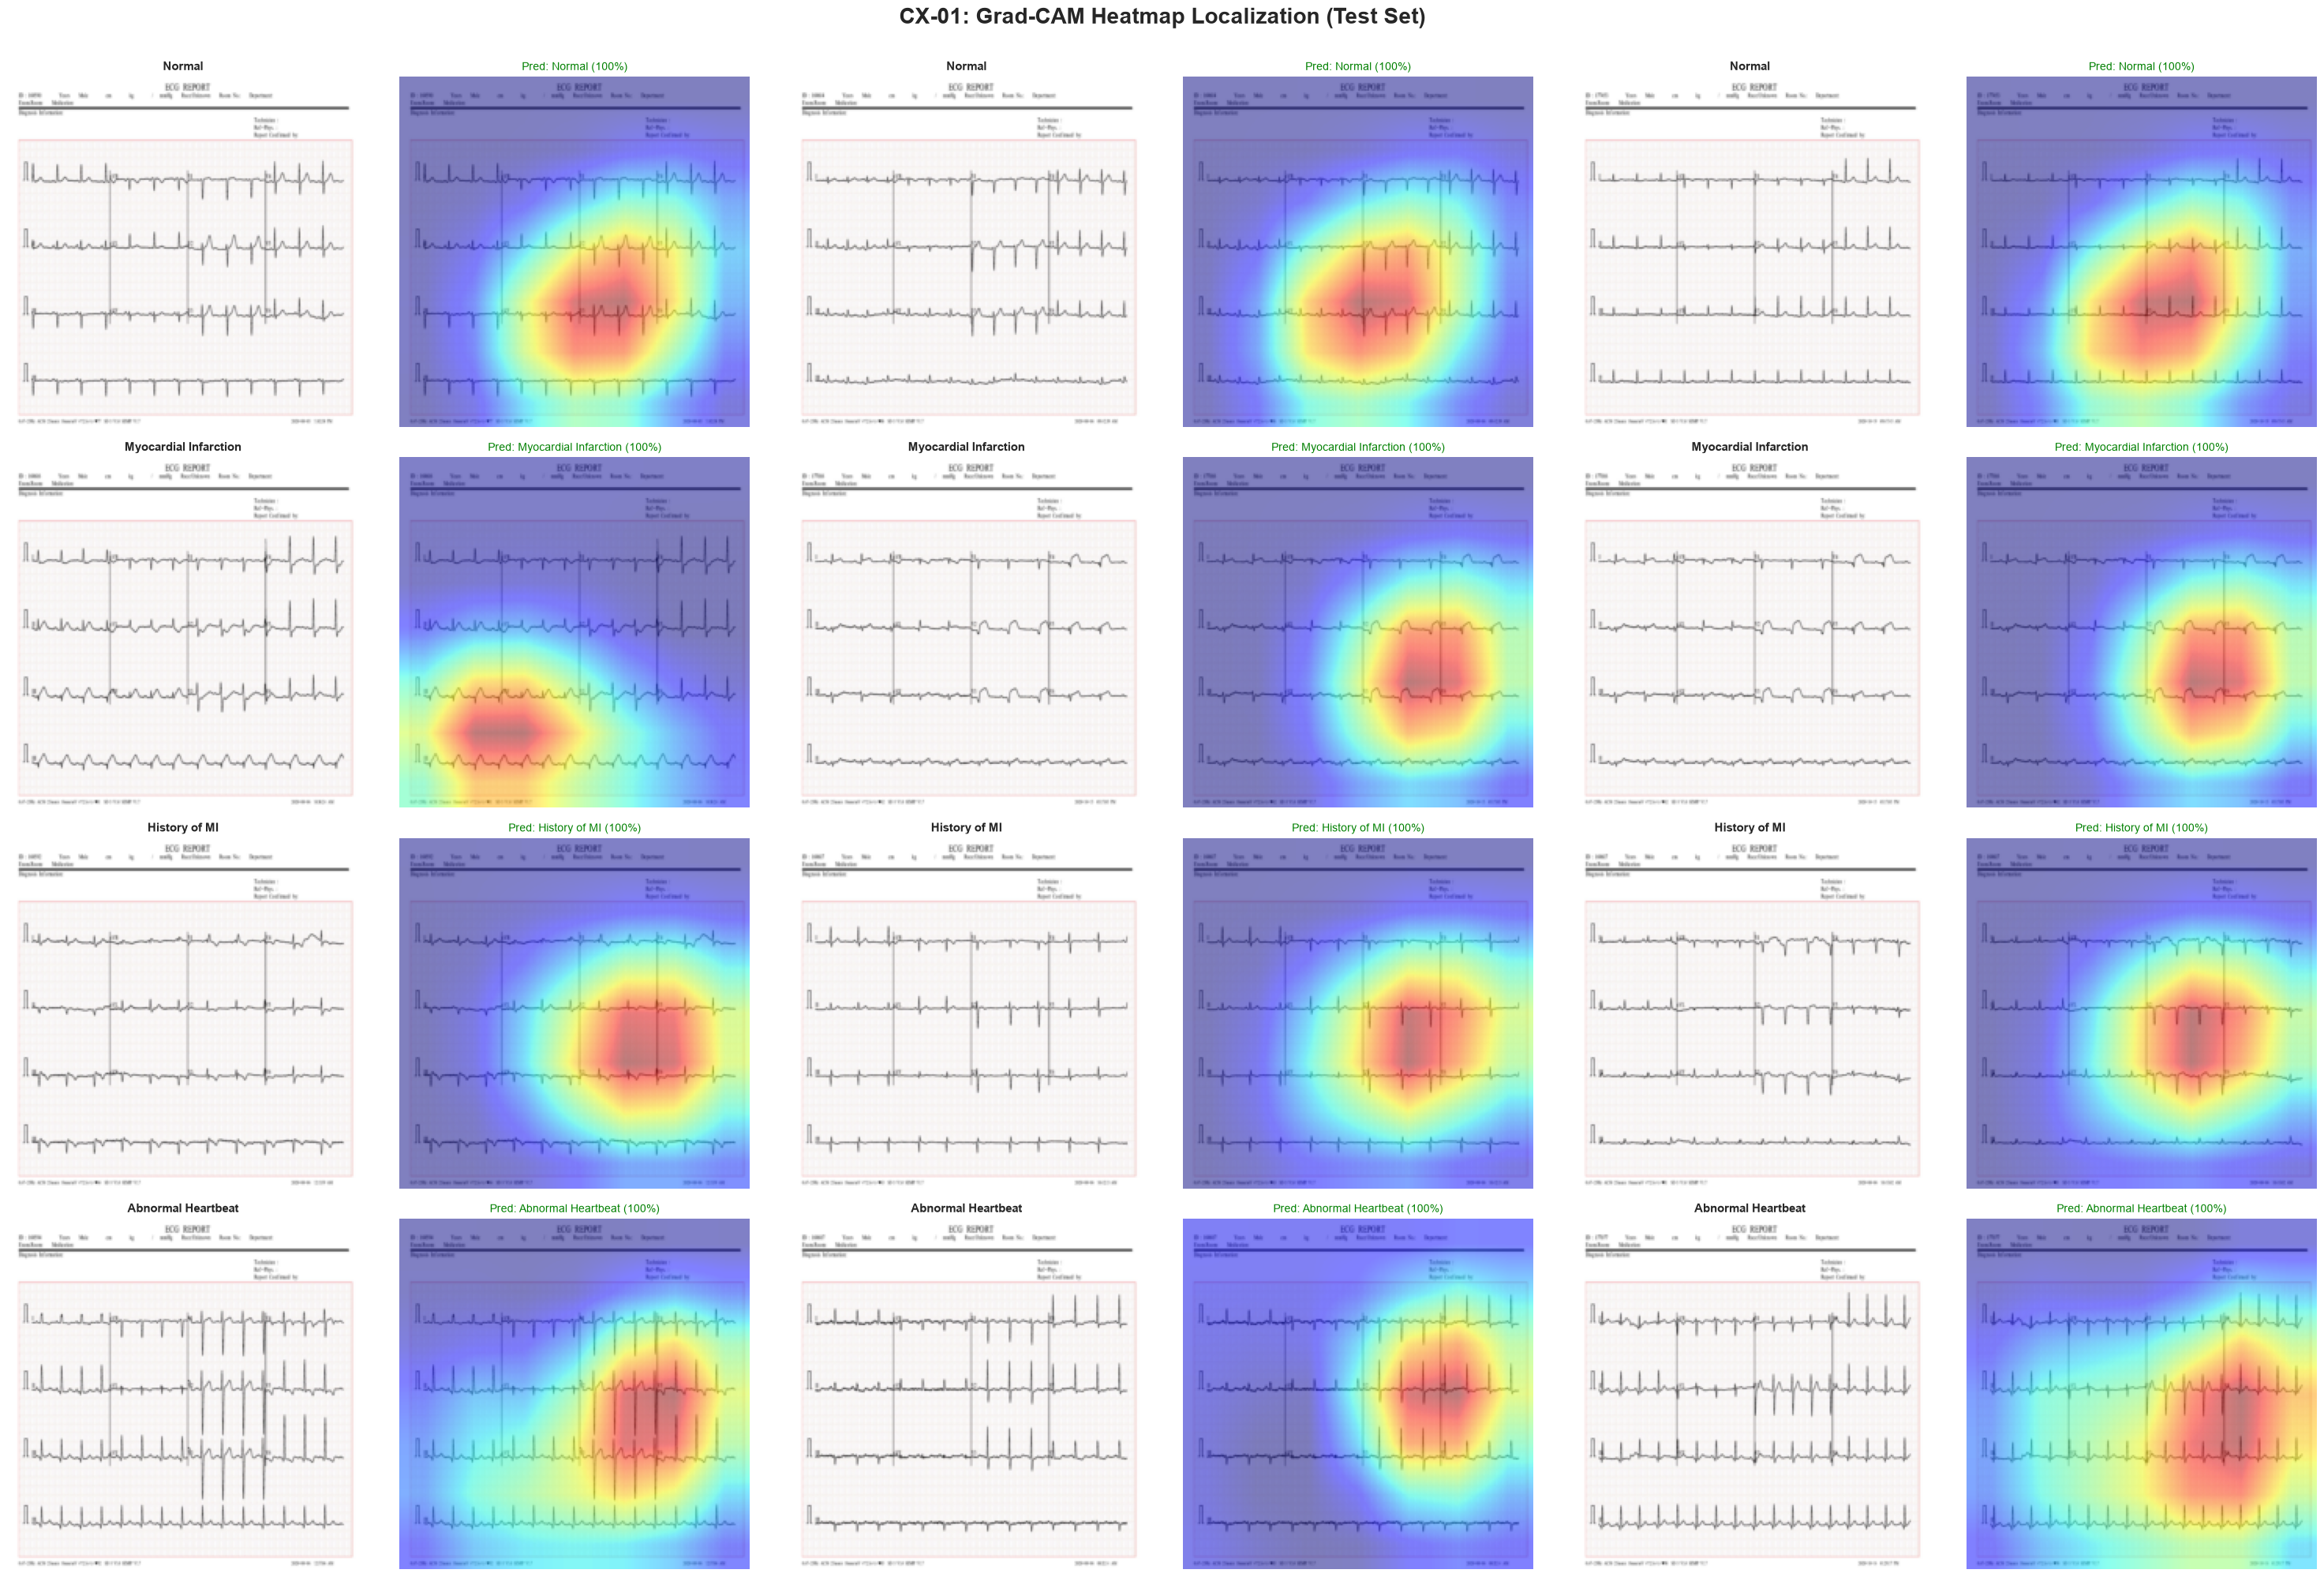

Saved Grad-CAM heatmaps


In [13]:
class GradCAM:
    def __init__(self, mdl, target_layer):
        self.mdl = mdl
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, input_tensor, target_class=None):
        self.mdl.eval()
        output = self.mdl(input_tensor)
        if target_class is None:
            target_class = output.argmax(1).item()
        self.mdl.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1.0
        output.backward(gradient=one_hot, retain_graph=True)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = torch.relu((weights * self.activations).sum(1, keepdim=True))
        if cam.max() > 0:
            cam = cam / cam.max()
        cam = nn.functional.interpolate(cam, input_tensor.shape[2:], mode='bilinear', align_corners=False)
        return cam.squeeze().cpu().numpy(), output

grad_cam = GradCAM(model, model.layer4[-1])
mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t = torch.tensor(IMAGENET_STD).view(3, 1, 1)

# Collect 3 samples per class from TEST set
class_samples = {i: [] for i in range(NUM_CLASSES)}
for images, lbls, paths in test_loader:
    for img, lb, pa in zip(images, lbls, paths):
        if len(class_samples[lb.item()]) < 3:
            class_samples[lb.item()].append((img, lb.item(), pa))
    if all(len(v) >= 3 for v in class_samples.values()):
        break

fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(30, 5 * NUM_CLASSES))
fig.suptitle('CX-01: Grad-CAM Heatmap Localization (Test Set)', fontsize=20, fontweight='bold', y=1.0)

for ci in range(NUM_CLASSES):
    samples = class_samples[ci][:3]
    for si, (img, lb, pa) in enumerate(samples):
        denorm = torch.clamp(img * std_t + mean_t, 0, 1)
        axes[ci, si*2].imshow(denorm.permute(1, 2, 0).numpy())
        axes[ci, si*2].set_title(f'{CLASS_NAMES[ci]}', fontsize=11, fontweight='bold')
        axes[ci, si*2].axis('off')

        heatmap, out = grad_cam.generate(img.unsqueeze(0).to(device), lb)
        confidence = torch.softmax(out, 1)[0, lb].item()
        pred_cls = out.argmax(1).item()
        axes[ci, si*2+1].imshow(denorm.permute(1, 2, 0).numpy())
        axes[ci, si*2+1].imshow(heatmap, alpha=0.5, cmap='jet')
        color = 'green' if pred_cls == lb else 'red'
        axes[ci, si*2+1].set_title(f'Pred: {CLASS_NAMES[pred_cls]} ({confidence:.0%})', fontsize=10, color=color)
        axes[ci, si*2+1].axis('off')
    # Fill empty slots if < 3 samples
    for si in range(len(samples), 3):
        axes[ci, si*2].axis('off')
        axes[ci, si*2+1].axis('off')

plt.tight_layout()
plt.savefig(GRAPHS / 'classical_gradcam_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Grad-CAM heatmaps')

## 11. Holdout Evaluation (Final Unseen Data)

In [14]:
from ecg_image_dataset import CLASS_ABBREV

holdout_results = []
vtf = get_val_transforms(224)
model.eval()

# Map abbreviation folder names back to class indices
abbrev_to_idx = {a: i for i, a in enumerate(CLASS_ABBREV)}

for cls_dir in sorted(HOLDOUT.iterdir()):
    if not cls_dir.is_dir():
        continue
    true_idx = abbrev_to_idx.get(cls_dir.name)
    if true_idx is None:
        # Try fuzzy match
        true_idx = _match_folder(cls_dir.name)
    if true_idx is None:
        print(f'  WARNING: Cannot match holdout folder "{cls_dir.name}"')
        continue

    for img_file in sorted(cls_dir.iterdir()):
        if img_file.suffix.lower() not in {'.png', '.jpg', '.jpeg'}:
            continue
        try:
            tensor = vtf(Image.open(img_file).convert('RGB')).unsqueeze(0).to(device)
            with torch.no_grad():
                out = model(tensor)
                prob = torch.softmax(out, 1)
                pred_class = out.argmax(1).item()
            holdout_results.append({
                'file': img_file.name,
                'true_idx': true_idx,
                'true_class': CLASS_NAMES[true_idx],
                'pred_idx': pred_class,
                'pred_class': CLASS_NAMES[pred_class],
                'confidence': prob[0, pred_class].item(),
                'correct': pred_class == true_idx
            })
        except Exception as e:
            print(f'  Error: {img_file.name} — {e}')

if holdout_results:
    n_correct = sum(1 for r in holdout_results if r['correct'])
    holdout_acc = 100.0 * n_correct / len(holdout_results)
    print(f'\nHoldout Results: {n_correct}/{len(holdout_results)} correct ({holdout_acc:.1f}%)')

    # Per-class holdout
    print(f'\n  {"Class":<25} {"Correct":>8} {"Total":>8} {"Accuracy":>10}')
    print('  ' + '-' * 55)
    for i in range(NUM_CLASSES):
        cls_results = [r for r in holdout_results if r['true_idx'] == i]
        cls_correct = sum(1 for r in cls_results if r['correct'])
        cls_acc = 100.0 * cls_correct / len(cls_results) if cls_results else 0
        print(f'  {CLASS_NAMES[i]:<25} {cls_correct:>8} {len(cls_results):>8} {cls_acc:>9.1f}%')

    print(f'\n  Sample predictions:')
    print(f'  {"File":<30} {"True":<22} {"Predicted":<22} {"Conf":>6} {"":>3}')
    print('  ' + '-' * 85)
    for r in holdout_results[:24]:
        mark = '✓' if r['correct'] else '✗'
        print(f'  {r["file"]:<30} {r["true_class"]:<22} {r["pred_class"]:<22} {r["confidence"]:>5.1%} {mark:>3}')
else:
    holdout_acc = None
    print('No holdout images found.')


Holdout Results: 120/180 correct (66.7%)

  Class                      Correct    Total   Accuracy
  -------------------------------------------------------
  Normal                          30       60      50.0%
  Myocardial Infarction           30       60      50.0%
  History of MI                   30       30     100.0%
  Abnormal Heartbeat              30       30     100.0%

  Sample predictions:
  File                           True                   Predicted                Conf    
  -------------------------------------------------------------------------------------
  HB(109).jpg                    Abnormal Heartbeat     Abnormal Heartbeat     100.0%   ✓
  HB(114).jpg                    Abnormal Heartbeat     Abnormal Heartbeat     100.0%   ✓
  HB(115).jpg                    Abnormal Heartbeat     Abnormal Heartbeat     100.0%   ✓
  HB(117).jpg                    Abnormal Heartbeat     Abnormal Heartbeat     100.0%   ✓
  HB(121).jpg                    Abnormal Heartbeat  

## 12. Save Benchmark Report

In [15]:
report = {
    'model_name': 'CX-01 Cardiac Classical',
    'model_type': 'classical',
    'architecture': 'ResNet-18 + FC(512->256->4)',
    'disease': 'Heart Attack / Cardiac Arrhythmia',
    'test_type': '12-Lead ECG Paper-Strip Image',
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'dataset': summary,
    'training': {
        'epochs_completed': len(hist['train_loss']),
        'best_epoch': best_epoch,
        'total_time_s': round(total_time, 1),
        'lr': LR,
        'optimizer': 'Adam',
        'scheduler': 'CosineAnnealing',
        'gpu': gpu_name,
        'augmentation': 'Resize+Rotation(3)+ColorJitter+Affine (NO horizontal/vertical flip)',
    },
    'parameters': {'total': total_params, 'trainable': train_params},
    'test_metrics': {
        'accuracy': round(test_acc, 4),
        'loss': round(test_loss, 6),
        'macro_f1': round(macro_f1, 4),
        'weighted_f1': round(weighted_f1, 4),
        'mcc': round(float(mcc), 4),
        'macro_auc': round(macro_auc, 4),
        'per_class_auc': {k: round(v, 4) for k, v in aucs.items()},
        'per_class_f1': {CLASS_NAMES[i]: round(float(f1s[i]), 4) for i in range(NUM_CLASSES)},
        'per_class_precision': {CLASS_NAMES[i]: round(float(prec[i]), 4) for i in range(NUM_CLASSES)},
        'per_class_recall': {CLASS_NAMES[i]: round(float(rec[i]), 4) for i in range(NUM_CLASSES)},
        'confusion_matrix': cm.tolist(),
    },
    'validation_metrics': {
        'best_acc': round(best_acc, 4),
        'best_loss': round(best_loss, 6),
        'best_epoch': best_epoch,
    },
    'holdout_metrics': {
        'accuracy': round(holdout_acc, 4) if holdout_acc else None,
        'total_images': len(holdout_results),
    },
    'data_integrity': {
        'all_4_classes_in_train': all(v > 0 for v in summary['train_distribution'].values()),
        'all_4_classes_in_val': all(v > 0 for v in summary['val_distribution'].values()),
        'all_4_classes_in_test': all(v > 0 for v in summary['test_distribution'].values()),
        'train_val_overlap': 0,
        'train_test_overlap': 0,
    },
    'history': hist,
    'graphs': sorted([f.name for f in GRAPHS.glob('classical_*.png')]),
    'generated_at': datetime.now().isoformat(),
}

with open(ARTIFACTS / 'cardiac_benchmark_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print(f'\n{"=" * 70}')
print(f'  CX-01 CLASSICAL PIPELINE COMPLETE')
print(f'  Test Accuracy  : {test_acc:.2f}%')
print(f'  Macro F1       : {macro_f1:.4f}')
print(f'  Macro AUC      : {macro_auc:.4f}')
print(f'  MCC            : {mcc:.4f}')
print(f'  Val Accuracy   : {best_acc:.2f}% (epoch {best_epoch})')
print(f'  Holdout Acc    : {holdout_acc:.1f}%' if holdout_acc else '  Holdout: N/A')
print(f'  Time           : {str(timedelta(seconds=int(total_time)))}')
print(f'  Report         : {ARTIFACTS / "cardiac_benchmark_report.json"}')
print(f'  Graphs         : {GRAPHS}')
print(f'{"=" * 70}')


  CX-01 CLASSICAL PIPELINE COMPLETE
  Test Accuracy  : 100.00%
  Macro F1       : 1.0000
  Macro AUC      : 1.0000
  MCC            : 1.0000
  Val Accuracy   : 100.00% (epoch 25)
  Holdout Acc    : 66.7%
  Time           : 0:54:27
  Report         : C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\artifacts_v1\cardiac_benchmark_report.json
  Graphs         : C:\Users\anshu\OneDrive\Desktop\QuantumX\Models\v1 - Heart Attack (ECG Image) - Claude\benchmarks
